### Baseline Model Development

### Gamma 2: Crop Yield Prediction

This notebook develops and evaluates Multiple Linear Regression models using:

1. the original cleaned features; and
2. the selected engineered features.

Both models use the same train-test split and evaluation metrics to ensure a fair comparison.

### 2. Import libraries

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import (
    cross_validate,
    KFold,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### 3. Set file paths

In [3]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError("Project root could not be identified.")

CLEANED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "crop_yield_cleaned.csv"
)

ENGINEERED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "crop_yield_engineered.csv"
)

RESULTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned dataset:", CLEANED_DATA_PATH)
print("Engineered dataset:", ENGINEERED_DATA_PATH)

Project root: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction
Cleaned dataset: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/data/processed/crop_yield_cleaned.csv
Engineered dataset: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/data/processed/crop_yield_engineered.csv


### 4. Load the datasets

In [4]:
if not CLEANED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {CLEANED_DATA_PATH}"
    )

if not ENGINEERED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Engineered dataset not found: {ENGINEERED_DATA_PATH}"
    )

df_original = pd.read_csv(CLEANED_DATA_PATH)
df_engineered = pd.read_csv(ENGINEERED_DATA_PATH)

print("Original dataset shape:", df_original.shape)
print("Engineered dataset shape:", df_engineered.shape)

Original dataset shape: (999, 8)
Engineered dataset shape: (999, 13)


In [5]:
df_original.head()

,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield,crop_type
0,1230,80,28,80,24,20,12.0,Corn
1,480,60,36,70,20,18,8.0,Sorghum
2,1250,75,29,78,22,19,11.0,Soybean
3,450,65,35,70,19,18,9.0,Sorghum
4,1200,80,27,79,22,19,11.0,Wheat


In [6]:
df_engineered.head()

,rainfall,fertilizer,temperature,nitrogen,phosphorus,potassium,yield,crop_type,total_npk,n_proportion,p_proportion,temperature_squared,rainfall_fertilizer_interaction
0,1230,80,28,80,24,20,12.0,Corn,124,0.645161,0.193548,784,98400
1,480,60,36,70,20,18,8.0,Sorghum,108,0.648148,0.185185,1296,28800
2,1250,75,29,78,22,19,11.0,Soybean,119,0.655462,0.184874,841,93750
3,450,65,35,70,19,18,9.0,Sorghum,107,0.654206,0.177570,1225,29250
4,1200,80,27,79,22,19,11.0,Wheat,120,0.658333,0.183333,729,96000


### 5. Validate required columns

In [7]:
original_required_columns = {
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium",
    "yield"
}

engineered_required_columns = {
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "total_npk",
    "n_proportion",
    "p_proportion",
    "temperature_squared",
    "rainfall_fertilizer_interaction",
    "yield"
}

missing_original = (
    original_required_columns
    .difference(df_original.columns)
)

missing_engineered = (
    engineered_required_columns
    .difference(df_engineered.columns)
)

if missing_original:
    raise KeyError(
        f"Missing original columns: {sorted(missing_original)}"
    )

if missing_engineered:
    raise KeyError(
        f"Missing engineered columns: {sorted(missing_engineered)}"
    )

print("All required columns are available.")

All required columns are available.


### 6. Check dataset alignment

The two datasets should contain the same observations in the same order.

In [8]:
if len(df_original) != len(df_engineered):
    raise ValueError(
        "The original and engineered datasets have different row counts."
    )

if not df_original["yield"].equals(df_engineered["yield"]):
    raise ValueError(
        "The target values are not aligned between the two datasets."
    )

print("The datasets are aligned.")

The datasets are aligned.


### 7. Define the feature sets
Original feature set

In [9]:
TARGET = "yield"

original_features = [
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium"
]

X_original = df_original[original_features].copy()

Engineered feature set

Note - Do not include the original nitrogen, phosphorus and potassium variables together with total_npk to avoid multicollinearity

In [10]:
engineered_features = [
    "crop_type",
    "rainfall",
    "temperature",
    "fertilizer",
    "total_npk",
    "n_proportion",
    "p_proportion",
    "temperature_squared",
    "rainfall_fertilizer_interaction"
]

X_engineered = df_engineered[engineered_features].copy()
y = df_original[TARGET].copy()

print("Original feature matrix:", X_original.shape)
print("Engineered feature matrix:", X_engineered.shape)
print("Target vector:", y.shape)

Original feature matrix: (999, 7)
Engineered feature matrix: (999, 9)
Target vector: (999,)


### 8. Create one common train-test split
This ensures that both models are evaluated on exactly the same observations.

In [16]:
train_indices, test_indices = train_test_split(
    df_original.index,
    test_size=0.20,
    random_state=42
)

X_original_train = X_original.loc[train_indices]
X_original_test = X_original.loc[test_indices]

X_engineered_train = X_engineered.loc[train_indices]
X_engineered_test = X_engineered.loc[test_indices]

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print("Training observations:", len(train_indices))
print("Testing observations:", len(test_indices))

Training observations: 799
Testing observations: 200


### 9. Build the preprocessing and modelling pipeline

In [18]:
def build_linear_regression_pipeline(
    feature_data: pd.DataFrame
) -> Pipeline:
    """
    Build a preprocessing and Multiple Linear Regression pipeline.
    """

    categorical_features = ["crop_type"]

    numerical_features = [
        column
        for column in feature_data.columns
        if column not in categorical_features
    ]

    numerical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ])

    preprocessor = ColumnTransformer([
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ])

    model_pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ])

    return model_pipeline

### 10. Define the evaluation function

In [19]:
def evaluate_regression_model(
    model: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series
):
    """
    Fit and evaluate a regression model.
    """

    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    results = {
        "Train MAE": mean_absolute_error(
            y_train,
            train_predictions
        ),
        "Test MAE": mean_absolute_error(
            y_test,
            test_predictions
        ),
        "Train RMSE": np.sqrt(
            mean_squared_error(
                y_train,
                train_predictions
            )
        ),
        "Test RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                test_predictions
            )
        ),
        "Train R2": r2_score(
            y_train,
            train_predictions
        ),
        "Test R2": r2_score(
            y_test,
            test_predictions
        )
    }

    return results, test_predictions

### 11. Fit the original-feature model

In [20]:
original_model = build_linear_regression_pipeline(
    X_original_train
)

original_results, original_predictions = (
    evaluate_regression_model(
        original_model,
        X_original_train,
        X_original_test,
        y_train,
        y_test
    )
)

original_results

{'Train MAE': 2.3132551826819667,
 'Test MAE': 2.534186082885817,
 'Train RMSE': np.float64(2.7185169928832393),
 'Test RMSE': np.float64(2.939089394683369),
 'Train R2': 0.03541522366994321,
 'Test R2': -0.002598751643510644}

The model showed weak predictive performance. The training and test errors were similar, with MAE values of 2.31 and 2.53 and RMSE values of 2.72 and 2.94, respectively. This suggests that the model did not substantially overfit the training data.

However, the training (R^2) value of 0.035 indicates that the model explained only about 3.5% of the variation in crop yield. The test (R^2) was slightly negative at -0.003, meaning that the model performed marginally worse than predicting the mean yield for all test observations.

Overall, the Multiple Linear Regression model underfit the data, suggesting that the relationships between the predictors and crop yield were not adequately captured by the linear model.


### 12. Fit the engineered-feature model

In [21]:
engineered_model = build_linear_regression_pipeline(
    X_engineered_train
)

engineered_results, engineered_predictions = (
    evaluate_regression_model(
        engineered_model,
        X_engineered_train,
        X_engineered_test,
        y_train,
        y_test
    )
)

engineered_results

{'Train MAE': 2.297430761540758,
 'Test MAE': 2.552522037683969,
 'Train RMSE': np.float64(2.7070353823080753),
 'Test RMSE': np.float64(2.9452578317703613),
 'Train R2': 0.043545832592207234,
 'Test R2': -0.006811591977007092}

The Multiple Linear Regression model using engineered features also showed weak predictive performance. The training and test MAE values were 2.30 and 2.55, while the RMSE values were 2.71 and 2.95, respectively. The relatively small differences between the training and test errors suggest that the model did not substantially overfit the training data.

However, the training (R^2) value of 0.044 indicates that the model explained only about 4.4% of the variation in crop yield. The test (R^2) was negative at -0.007, meaning the model performed slightly worse than predicting the average yield for all test observations.

Compared with the model using the original features, the engineered-feature model produced a slightly higher test MAE and RMSE and a slightly lower test (R^2). Therefore, the engineered features did not improve the predictive performance of Multiple Linear Regression.


### Checks

In [35]:
original_model.fit(X_original_train, y_train)

preprocessor = original_model.named_steps["preprocessor"]
numeric_transformer = preprocessor.named_transformers_["numerical"]
scaler = numeric_transformer.named_steps["scaler"]

print("Scaler means:")
print(scaler.mean_)

print("\nScaler standard deviations:")
print(scaler.scale_)

Scaler means:
[892.06633292  29.60700876  73.51564456  74.20650814  21.87484355
  16.86483104]

Scaler standard deviations:
[305.64856152   5.79765184  13.92018885   8.51567987   4.23045226
   4.01333849]


In [36]:
numeric_features = [
    "rainfall",
    "temperature",
    "fertilizer",
    "nitrogen",
    "phosphorus",
    "potassium"
]

numeric_pipeline = (
    original_model
    .named_steps["preprocessor"]
    .named_transformers_["numerical"]
)

X_numeric_scaled = numeric_pipeline.transform(
    X_original_train[numeric_features]
)

scaled_df = pd.DataFrame(
    X_numeric_scaled,
    columns=numeric_features,
    index=X_original_train.index
)

print("Scaled means:")
print(scaled_df.mean().round(4))

print("\nScaled standard deviations:")
print(scaled_df.std(ddof=0).round(4))

Scaled means:
rainfall       0.0
temperature    0.0
fertilizer    -0.0
nitrogen       0.0
phosphorus     0.0
potassium     -0.0
dtype: float64

Scaled standard deviations:
rainfall       1.0
temperature    1.0
fertilizer     1.0
nitrogen       1.0
phosphorus     1.0
potassium      1.0
dtype: float64


The numerical predictors were successfully standardised using StandardScaler. After transformation, each training feature had a mean of approximately zero and a standard deviation of one, confirming that the scaling step was applied correctly. The scaler was fitted only on the training data and then used to transform the test data, thereby avoiding data leakage.

### 13. Compare model performance

In [22]:
comparison_results = pd.DataFrame([
    {
        "Model": "Multiple Linear Regression: Original Features",
        **original_results
    },
    {
        "Model": "Multiple Linear Regression: Engineered Features",
        **engineered_results
    }
])

comparison_results.round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Multiple Linear Regression: Original Features,2.3133,2.5342,2.7185,2.9391,0.0354,-0.0026
1,Multiple Linear Regression: Engineered Features,2.2974,2.5525,2.7070,2.9453,0.0435,-0.0068


The two Multiple Linear Regression models produced very similar results. The engineered-feature model achieved slightly lower training MAE and RMSE and a slightly higher training (R^2), indicating a marginally better fit to the training data.

However, on the test data, the original-feature model performed slightly better. It recorded a lower test MAE of 2.534 compared with 2.553, a lower test RMSE of 2.939 compared with 2.945, and a less negative test (R^2) of -0.003 compared with -0.007.

Overall, the engineered features did not improve the generalisation performance of Multiple Linear Regression. Both models underfit the data and performed slightly worse than predicting the mean yield on the test set. The original-feature model may therefore be retained as the stronger linear baseline because it achieved marginally better test performance with fewer derived variables.


### Save the results

In [23]:
RESULTS_PATH = (
    RESULTS_DIR
    / "baseline_model_results.csv"
)

comparison_results.to_csv(
    RESULTS_PATH,
    index=False
)

print(f"Results saved to: {RESULTS_PATH}")

Results saved to: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/reports/baseline_model_results.csv


### 14. Conduct cross-validation

A single test split may be affected by chance. Five-fold cross-validation provides a more stable comparison.

In [24]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

### Original features

In [25]:
original_cv_results = cross_validate(
    build_linear_regression_pipeline(X_original),
    X_original,
    y,
    cv=cv,
    scoring=scoring
)

### Engineered features

In [26]:
engineered_cv_results = cross_validate(
    build_linear_regression_pipeline(X_engineered),
    X_engineered,
    y,
    cv=cv,
    scoring=scoring
)

In [28]:
cv_comparison = pd.DataFrame([
    {
        "Model": "Original Features",
        "CV MAE Mean": -original_cv_results[
            "test_mae"
        ].mean(),
        "CV MAE SD": original_cv_results[
            "test_mae"
        ].std(),
        "CV RMSE Mean": -original_cv_results[
            "test_rmse"
        ].mean(),
        "CV RMSE SD": original_cv_results[
            "test_rmse"
        ].std(),
        "CV R2 Mean": original_cv_results[
            "test_r2"
        ].mean(),
        "CV R2 SD": original_cv_results[
            "test_r2"
        ].std()
    },
    {
        "Model": "Engineered Features",
        "CV MAE Mean": -engineered_cv_results[
            "test_mae"
        ].mean(),
        "CV MAE SD": engineered_cv_results[
            "test_mae"
        ].std(),
        "CV RMSE Mean": -engineered_cv_results[
            "test_rmse"
        ].mean(),
        "CV RMSE SD": engineered_cv_results[
            "test_rmse"
        ].std(),
        "CV R2 Mean": engineered_cv_results[
            "test_r2"
        ].mean(),
        "CV R2 SD": engineered_cv_results[
            "test_r2"
        ].std()
    }
])

cv_comparison.round(4)

,Model,CV MAE Mean,CV MAE SD,CV RMSE Mean,CV RMSE SD,CV R2 Mean,CV R2 SD
0,Original Features,2.3841,0.1657,2.7926,0.1266,0.0014,0.0169
1,Engineered Features,2.3780,0.1697,2.7892,0.1327,0.0039,0.0255


The five-fold cross-validation results show that the original and engineered feature sets performed almost identically. The engineered-feature model recorded slightly lower mean MAE and RMSE values, at 2.378 and 2.789 respectively, compared with 2.384 and 2.793 for the original-feature model. It also achieved a marginally higher mean (R^2) of 0.004, compared with 0.001 for the original features.

However, these differences are very small and are smaller than the variation across the folds. The engineered-feature model also had slightly higher standard deviations for MAE, RMSE and (R^2), suggesting marginally less stable performance across the folds.

Overall, cross-validation does not provide strong evidence that the engineered features meaningfully improved Multiple Linear Regression. Both models explained almost none of the variation in crop yield, confirming that the linear models underfit the data. The original-feature model may therefore remain the preferred baseline because it is simpler and achieved slightly better performance on the held-out test set.


### Save:

In [29]:
CV_RESULTS_PATH = (
    RESULTS_DIR
    / "baseline_cross_validation_results.csv"
)

cv_comparison.to_csv(
    CV_RESULTS_PATH,
    index=False
)

print(f"Cross-validation results saved to: {CV_RESULTS_PATH}")

Cross-validation results saved to: /Users/ronkecrown/Documents/gamma2-crop-yield-prediction/reports/baseline_cross_validation_results.csv


### 15. Actual versus predicted plot

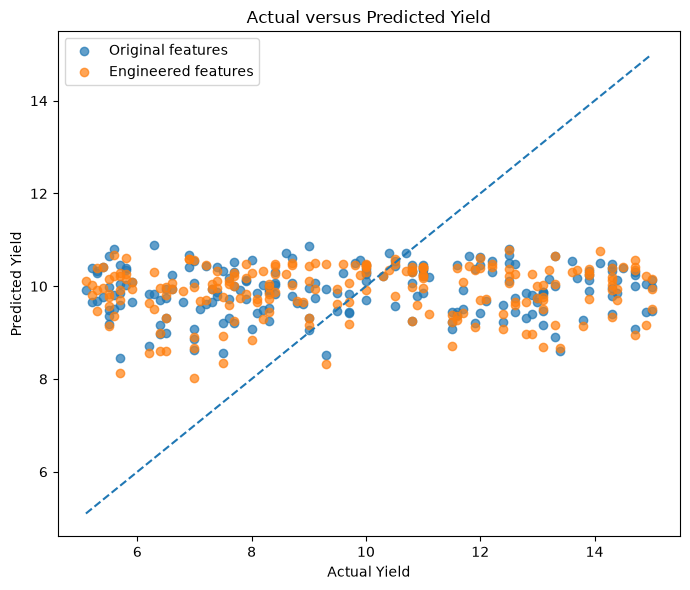

In [30]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    original_predictions,
    alpha=0.7,
    label="Original features"
)

plt.scatter(
    y_test,
    engineered_predictions,
    alpha=0.7,
    label="Engineered features"
)

minimum_value = min(
    y_test.min(),
    original_predictions.min(),
    engineered_predictions.min()
)

maximum_value = max(
    y_test.max(),
    original_predictions.max(),
    engineered_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual versus Predicted Yield")
plt.legend()
plt.tight_layout()

PREDICTION_FIGURE_PATH = (
    FIGURES_DIR
    / "baseline_actual_vs_predicted.png"
)

plt.savefig(
    PREDICTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The actual-versus-predicted plot shows that predictions from both Multiple Linear Regression models are concentrated around the mean yield rather than following the 45-degree reference line. The models overestimate low yields and underestimate high yields, indicating strong underfitting. The substantial overlap between the original- and engineered-feature predictions further confirms that feature engineering did not meaningfully improve the linear model’s predictive performance.

### 16. Residual Plots

In [31]:
original_residuals = y_test - original_predictions
engineered_residuals = y_test - engineered_predictions

### Original model

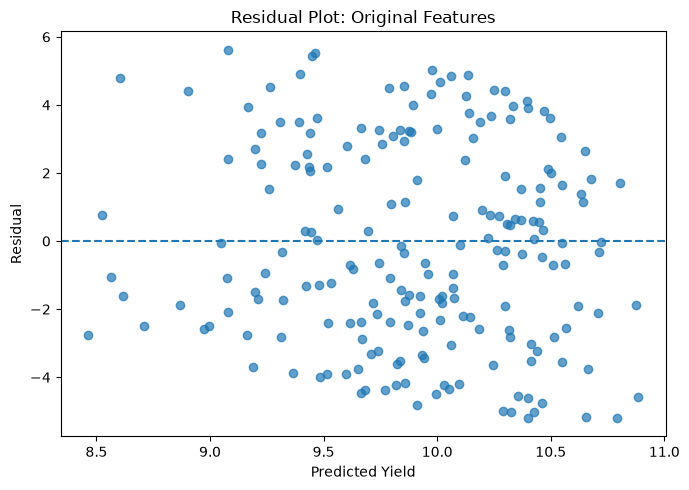

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(
    original_predictions,
    original_residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("Residual Plot: Original Features")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "baseline_original_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The residual plot for the original-feature model shows a wide spread of errors around the zero line. Although the residuals occur on both sides of zero, they are not tightly or randomly concentrated around it. The model produces large positive and negative residuals across a narrow range of predicted yields, indicating that it fails to capture important variation in crop yield. This pattern is consistent with underfitting and the model’s very low R
2
.

### Engineered model

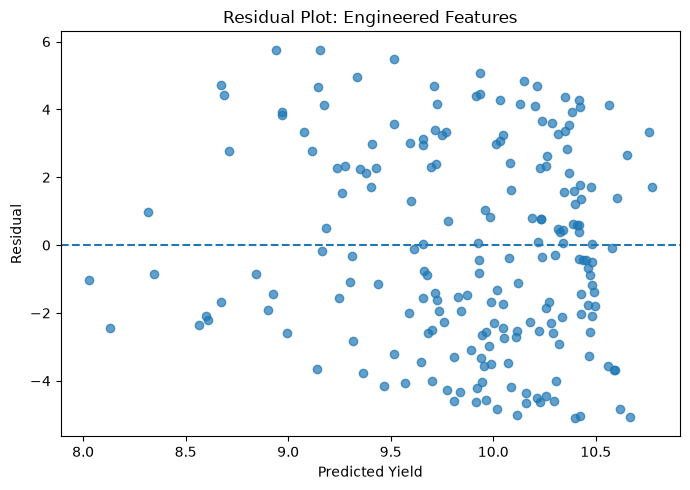

In [33]:
plt.figure(figsize=(7, 5))

plt.scatter(
    engineered_predictions,
    engineered_residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("Residual Plot: Engineered Features")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "baseline_engineered_residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The residual plot for the engineered-feature model shows a wide spread of positive and negative errors around the zero line. The residuals are not tightly or randomly concentrated around zero, and large errors remain across a narrow range of predicted yields. This indicates that the engineered features did not resolve the underfitting problem. The pattern is consistent with the model’s negative test R
2
 and confirms that Multiple Linear Regression is not adequately capturing the relationships in the data.

### Overall,
The weak MLR performance may reflect the model’s inability to capture nonlinear and crop-specific relationships. However, the near-zero cross-validation R^2
 also suggests that the available predictors may contain limited information about yield, or that important yield-determining variables are absent. The advanced models will help distinguish between model under-complexity and limited data signal.

### 17. Select the better baseline

In [34]:
original_rmse = original_results["Test RMSE"]
engineered_rmse = engineered_results["Test RMSE"]

if engineered_rmse < original_rmse:
    selected_baseline = (
        "Multiple Linear Regression with engineered features"
    )
else:
    selected_baseline = (
        "Multiple Linear Regression with original features"
    )

print("Selected baseline:", selected_baseline)

Selected baseline: Multiple Linear Regression with original features
